---
title: 'Optimale Finanzierung'
author: 'Jacques Mock Schindler'
format: pdf
df-print: kable
---


# Optimale Finanzierung

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
liabilities = np.linspace(1,99, 2000)

In [6]:
df = pd.DataFrame(liabilities, columns=['liabilities'])
df['equity'] = 100 - df['liabilities']
df['EBIT'] = 10

# RoI einheitlich in % (10%)
df['RoI'] = (df['EBIT'] / (df['liabilities'] + df['equity'])) * 100

# Szenario A: Günstiger Zins (5%) -> Positiver Leverage-Effekt
df['profit5'] = df['EBIT'] - (df['liabilities'] * 0.05)
df['RoE5'] = (df['profit5'] / df['equity']) * 100

# Szenario B: Teurer Zins (15%) -> Negativer Leverage-Effekt
df['profit15'] = df['EBIT'] - (df['liabilities'] * 0.15)
df['RoE15'] = (df['profit15'] / df['equity']) * 100

df = df.round(2)
df

,liabilities,equity,EBIT,RoI,profit5,RoE5,profit15,RoE15
0,1.00,99.00,10,10.0,9.95,10.05,9.85,9.95
1,1.05,98.95,10,10.0,9.95,10.05,9.84,9.95
2,1.10,98.90,10,10.0,9.95,10.06,9.84,9.94
3,1.15,98.85,10,10.0,9.94,10.06,9.83,9.94
4,1.20,98.80,10,10.0,9.94,10.06,9.82,9.94
...,...,...,...,...,...,...,...,...
1995,98.80,1.20,10,10.0,5.06,423.03,-4.82,-403.03
1996,98.85,1.15,10,10.0,5.06,440.89,-4.83,-420.89
1997,98.90,1.10,10,10.0,5.05,460.35,-4.84,-440.35
1998,98.95,1.05,10,10.0,5.05,481.63,-4.84,-461.63


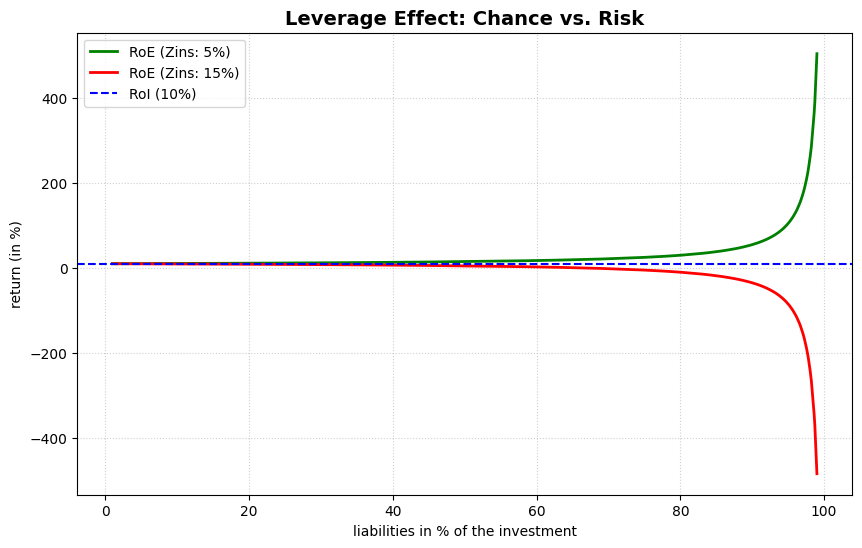

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Wir plotten gegen das FK auf der X-Achse!
ax.plot(df['liabilities'], df['RoE5'], label='RoE (Zins: 5%)', color='green', linewidth=2)
ax.plot(df['liabilities'], df['RoE15'], label='RoE (Zins: 15%)', color='red', linewidth=2)

# Die Nulllinie für die Gesamtkapitalrendite (RoI)
ax.axhline(y=10, color='blue', linestyle='--', label='RoI (10%)')

# Beschriftungen vollkommen eindeutig machen
ax.set_xlabel("liabilities in % of the investment")
ax.set_ylabel('return (in %)')
ax.set_title('Leverage Effect: Chance vs. Risk', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [9]:
from matplotlib import lines
def plot_leverage(roi: float, interest_rate: float):
    if roi > 1:
        roi = roi / 100
    if interest_rate > 1:
        interest_rate = interest_rate / 100

    liabilities = np.linspace(10,90,2000)
    df = pd.DataFrame(liabilities, columns=['Liabilities'])
    df['Assets'] = 100 - df['Liabilities']
    df['EBIT'] = 100 * roi
    df['Profit'] = df['EBIT'] - (df['Liabilities'] * interest_rate)
    df['RoE'] = (df['Profit'] / df['Assets']) * 100
    df['RoI'] = roi * 100
    df['Interest Rate'] = interest_rate * 100
    df = df.round(2)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['Liabilities'], df['RoE'], label='RoE',
            color='green', linewidth=2)
    ax.plot(df['Liabilities'], df['Interest Rate'], label='Interest Rate',
            color='red')
    ax.plot(df['Liabilities'], df['RoI'], label='RoI', color='blue')
    ax.axhline(y=0, linestyle='--', color='black')
    ax.set_ylabel('Return (in %)')
    ax.set_xlabel('Liabilities (in %)')
    ax.set_title('Leverage Effect', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    plt.show()
    print(df.head())

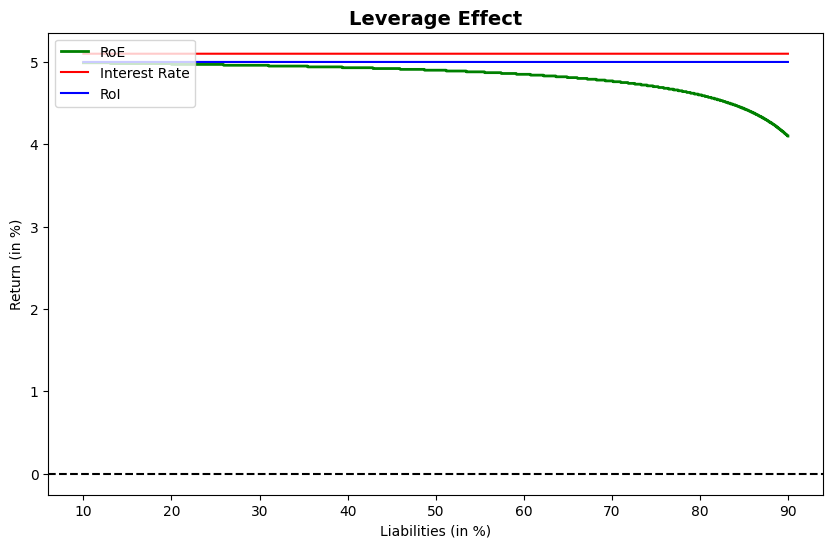

   Liabilities  Assets  EBIT  Profit   RoE  RoI  Interest Rate
0        10.00   90.00   5.0    4.49  4.99  5.0            5.1
1        10.04   89.96   5.0    4.49  4.99  5.0            5.1
2        10.08   89.92   5.0    4.49  4.99  5.0            5.1
3        10.12   89.88   5.0    4.48  4.99  5.0            5.1
4        10.16   89.84   5.0    4.48  4.99  5.0            5.1


In [10]:
plot_leverage(5, 5.1)

Bei der Formel in deinem Screenshot handelt es sich um die mathematische Darstellung des **Leverage-Effekts** (die Hebelwirkung des Fremdkapitals auf die Eigenkapitalrentabilität).

Um die Herleitung sauber durchzuführen, lassen wir den Faktor 100 aus deiner Ausgangsformel für den Anfang weg. Wir nehmen einfach an, dass alle Zinssätze und Rentabilitäten als Dezimalzahlen (z. B. 0,10 statt 10 %) angegeben werden. Am Ende kommt genau dasselbe heraus.

### 1. Definition der Variablen

Damit die Schritte nachvollziehbar sind, definieren wir zuerst die Buchstaben aus deinem Screenshot:

* $r$ = Eigenkapitalrentabilität ($\text{RoE}$)
* $i$ = Gesamtkapitalrentabilität
* $k$ = Fremdkapitalzinssatz
* $EK$ = Eigenkapital
* $FK$ = Fremdkapital
* $GK$ = Gesamtkapital (wobei gilt: $GK = EK + FK$)

---

### 2. Die Schritt-für-Schritt-Herleitung

**Ausgangspunkt:** Deine Definition des RoE (ohne den Faktor 100):


$$r = \frac{\text{Gewinn}}{EK}$$

**Schritt 1: Den Gewinn aufspalten**
Der Gewinn, der den Eigenkapitalgebern zusteht, ist der operative Gesamtgewinn des Unternehmens abzüglich der Zinsen, die an die Fremdkapitalgeber gezahlt werden müssen:


$$\text{Gewinn} = \text{Gesamtgewinn} - \text{Fremdkapitalzinsen}$$

**Schritt 2: Gesamtgewinn und Zinsen durch die Rentabilitäten ausdrücken**

* Aus der Definition der Gesamtkapitalrentabilität ($i = \frac{\text{Gesamtgewinn}}{GK}$) folgt: $\text{Gesamtgewinn} = i \cdot GK$
* Aus dem Fremdkapitalzinssatz ($k = \frac{\text{Fremdkapitalzinsen}}{FK}$) folgt: $\text{Fremdkapitalzinsen} = k \cdot FK$

Wenn wir das oben einsetzen, erhalten wir für den Gewinn:


$$\text{Gewinn} = (i \cdot GK) - (k \cdot FK)$$

**Schritt 3: Das Gesamtkapital ($GK$) ersetzen**
Da sich das Gesamtkapital aus Eigen- und Fremdkapital zusammensetzt ($GK = EK + FK$), ersetzen wir $GK$:


$$\text{Gewinn} = i \cdot (EK + FK) - k \cdot FK$$

Jetzt lösen wir die Klammer auf (ausmultiplizieren):


$$\text{Gewinn} = i \cdot EK + i \cdot FK - k \cdot FK$$

**Schritt 4: In die Ausgangsformel einsetzen**
Diesen Ausdruck für den Gewinn setzen wir nun oben in unsere allererste Formel ($r = \frac{\text{Gewinn}}{EK}$) ein:


$$r = \frac{i \cdot EK + i \cdot FK - k \cdot FK}{EK}$$

**Schritt 5: Den Bruch aufteilen und kürzen**
Wir können den großen Bruch in zwei separate Brüche zerlegen:


$$r = \frac{i \cdot EK}{EK} + \frac{i \cdot FK - k \cdot FK}{EK}$$

Im linken Teil kürzt sich das $EK$ komplett weg:


$$r = i + \frac{i \cdot FK - k \cdot FK}{EK}$$

**Schritt 6: Ausklammern im Zähler**
Im Zähler des rechten Bruchs steckt in beiden Summanden die Variable $FK$. Diese klammern wir aus:


$$r = i + \frac{FK \cdot (i - k)}{EK}$$

Wenn man das $FK$ jetzt noch vor oder hinter den Bruch zieht, entspricht es exakt der Schreibweise aus deinem Screenshot:


$$r = i + \frac{FK}{EK}(i - k)$$

---

### Das Ergebnis

Die Formel zeigt dir nun perfekt das Prinzip des Leverage-Effekts: Deine Eigenkapitalrentabilität ($r$) entspricht der Gesamtkapitalrentabilität ($i$), plus einem "Bonus" (oder Malus), der davon abhängt, wie viel Fremdkapital im Verhältnis zum Eigenkapital eingesetzt wird ($\frac{FK}{EK}$) und wie viel höher die Gesamtkapitalrentabilität im Vergleich zum Zinssatz ist ($(i - k)$).

Diese Brücke zwischen deinem Python-Code und der mathematischen Herleitung schließt die Lücke zwischen Theorie (Formel) und Praxis (Simulation).

Wenn du Code schreibst, tust du im Grunde genau das Gleiche wie bei der mathematischen Umformung – nur dass Python mit Variablen und Tabellen (DataFrames) rechnet, anstatt Terme auf dem Papier aufzulösen.

---

## 1. Die Übersetzung der Variablen (Notation)

Ein kleiner Stolperstein in deinem Notebook ist, dass ganz unten in der Markdown-Zelle die Buchstaben leicht verändert wurden im Vergleich zu unserem ersten Screenshot. Hier ist die exakte Übersetzungstabelle, damit nichts durcheinandergerät:

| Betriebswirtschaftlicher Begriff | Variable im Python-Code | Symbol (Formel Screenshot) | Symbol (Formel Notebook-Ende) |
| --- | --- | --- | --- |
| **Eigenkapitalrentabilität** | `RoE` / `RoE5` / `RoE15` | $r$ | $\text{RoE}$ |
| **Gesamtkapitalrentabilität** | `RoI` (hier fix 10%) | $i$ | $\text{RoI}$ |
| **Fremdkapitalzinssatz** | `interest_rate` (5% oder 15%) | $k$ | $i$ |
| **Eigenkapital** | `EK` / `Assets` | $EK$ | $\text{EK}$ |
| **Fremdkapital** | `FK` / `Liabilities` | $FK$ | $\text{FK}$ |

---

## 2. Code-Zeilen treffen auf Herleitungsschritte

Schauen wir uns an, wie deine Code-Logik exakt die mathematischen Schritte abbildet:

### Brücke A: Den Gewinn berechnen

In der mathematischen Herleitung (Schritt 2) haben wir den Gewinn definiert als:


$$\text{Gewinn} = (i \cdot GK) - (k \cdot FK)$$

In deinem Code wird das Gesamtkapital ($GK$) implizit auf $100$ gesetzt (`df['FK'] + df['EK'] = 100`). Daher entspricht dein `df['EBIT'] = 10` genau dem Term $i \cdot GK$ (nämlich $10\% \text{ von } 100$). Deine Code-Zeile lautet:

```python
df['Gewinn5'] = df['EBIT'] - (df['FK'] * 0.05)

```

Das ist die exakte Eins-zu-eins-Umsetzung der mathematischen Gewinn-Formel!

### Brücke B: Die Rentabilität berechnen

Der Ausgangspunkt der Herleitung war:


$$r = \frac{\text{Gewinn}}{EK}$$

Deine Code-Zeile zur Berechnung der Hebel-Kurve lautet:

```python
df['RoE5'] = (df['Gewinn5'] / df['EK']) * 100

```

Das `* 100` am Ende dient hier nur dazu, aus der Dezimalzahl (z. B. $0.05$) eine Prozentzahl ($5.0\%$) für die Grafik zu machen. Die mathematische Struktur ist identisch.

---

## 3. Die Simulation durch die Formelbrücke verstehen

Die Formel am Ende deines Notebooks lautet:


$$\text{RoE} = \text{RoI} + \frac{\text{FK}}{\text{EK}} \cdot (\text{RoI} - i)$$

Wenn du dir die Ausgabe deines DataFrames (`df.head()` und die letzten Zeilen) anschaust, erklärt diese Formel die Zahlen deines Plots:

* **Szenario A (Zins 5% – Grüne Linie):** Hier ist $\text{RoI} (10\%) > \text{Zins } i (5\%)$. Die Klammer $(\text{RoI} - i)$ ist positiv ($+5\%$). Wenn du nun den Hebel $\frac{\text{FK}}{\text{EK}}$ erhöhst (indem du dich von links nach rechts auf der X-Achse bewegst), wird dieser positive Wert immer weiter multipliziert. In Zeile 1999 hast du fast nur noch Fremdkapital ($99 : 1$). Der Hebelfaktor ist enorm hoch, weshalb dein `RoE5` auf gigantische $505\%$ ansteigt.
* **Szenario B (Zins 15% – Rote Linie):** Hier ist $\text{RoI} (10\%) < \text{Zins } i (15\%)$. Die Klammer $(\text{RoI} - i)$ ist negativ ($-5\%$). Erhöhst du jetzt das Fremdkapital, multiplizierst du einen *negativen* Effekt. Das geliehene Geld kostet dich mehr, als es einbringt. Dein `RoE15` stürzt folgerichtig in den Keller ($-485\%$).

Die Formel ist also nichts anderes als das mathematische Gesetz, das bestimmt, wie sich die Linien in deiner Grafik verhalten müssen.

---

Möchtest du für deinen Auftrag noch formulieren, wo genau der kritische Wendepunkt (Risiko) bei dieser Hebelwirkung liegt, wenn sich der RoI im Zeitverlauf ändert?

Auftrag: Beobachtung als Text formulieren.

$$
\text{RoE} = \text{RoI} + \frac{\text{FK}}{\text{EK}} \cdot (\text{RoI} - i)
$$